
# Second part  - Multi-Label Classification with CLIP (Linear Probing + Fine-Tuning)


In [ ]:
# ── Install dependencies for Phase 2 (classification) ─────────────────────
!pip install -q transformers scikit-learn

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPModel, CLIPProcessor
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import matplotlib.pyplot as plt

print('Phase 2 dependencies loaded')
print('CUDA available:', torch.cuda.is_available())


Phase 2 dependencies loaded
CUDA available: True


In [ ]:
# ── Standalone imports ────────────────────────────────────────────────────
import os
import json
import glob
import uuid
import numpy as np
import pandas as pd
from PIL import Image
from google.colab import drive, files

print('Standalone imports ready')

Standalone imports ready


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile

ZIP_PATH_ON_DRIVE = "/content/drive/MyDrive/accessscan_dataset.zip"

DATA_ROOT = "/content/data_extracted"
os.makedirs(DATA_ROOT, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH_ON_DRIVE, 'r') as zf:
    zf.extractall(DATA_ROOT)

print('Extracted to:', DATA_ROOT)
print('Contents:', os.listdir(DATA_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted to: /content/data_extracted
Contents: ['accessscan_dataset (2)']


In [ ]:
# ── Rebuild metadata from JSON sidecars, with a folder-name fallback ────────

LABEL_COLS = ["has_ramp", "has_disabled_parking", "has_obstacle"]

SCENARIO_LABELS = {
    "stairs_only": {"has_ramp": False, "has_disabled_parking": False, "has_obstacle": False},
    "stairs_and_ramp": {"has_ramp": True, "has_disabled_parking": False, "has_obstacle": False},
    "fully_accessible": {"has_ramp": True, "has_disabled_parking": True, "has_obstacle": False},
    "stairs_with_disabled_parking": {"has_ramp": False, "has_disabled_parking": True, "has_obstacle": False},
    "ramp_blocked_by_obstacle": {"has_ramp": True, "has_disabled_parking": False, "has_obstacle": True},
}


def load_dataset_metadata(data_root):
    records = []
    image_paths = (
        glob.glob(os.path.join(data_root, "**", "*.png"), recursive=True) +
        glob.glob(os.path.join(data_root, "**", "*.jpg"), recursive=True)
    )

    for img_path in image_paths:
        json_path = os.path.splitext(img_path)[0] + ".json"
        filename = os.path.basename(img_path)
        scenario_name = os.path.basename(os.path.dirname(img_path))
        is_augmented = "__aug" in filename

        if os.path.exists(json_path):
            with open(json_path, "r", encoding="utf-8") as f:
                meta = json.load(f)
        else:
            if scenario_name not in SCENARIO_LABELS:
                continue  # unrecognized folder - skip rather than guess wrong
            meta = {
                "filename": filename,
                "scenario": scenario_name,
                "is_augmented": is_augmented,
                "source_image": filename.replace("__aug", "") if is_augmented else None,
                **SCENARIO_LABELS[scenario_name],
            }

        meta["path"] = img_path
        records.append(meta)

    return records

records = load_dataset_metadata(DATA_ROOT)
df = pd.DataFrame(records)
for col in LABEL_COLS:
    df[col] = df[col].astype(bool)
if "is_augmented" not in df.columns:
    df["is_augmented"] = False

print(f'Loaded {len(df)} images')
print('\nPer scenario:')
print(df["scenario"].value_counts())
print('\nLabel counts:')
for col in LABEL_COLS:
    print(f'  {col}: {df[col].sum()} / {len(df)}')

Loaded 1646 images

Per scenario:
scenario
ramp_blocked_by_obstacle        498
stairs_only                     302
fully_accessible                300
stairs_and_ramp                 300
stairs_with_disabled_parking    246
Name: count, dtype: int64

Label counts:
  has_ramp: 1098 / 1646
  has_disabled_parking: 546 / 1646
  has_obstacle: 498 / 1646


In [ ]:
# ── Cap over-represented scenarios (e.g. stairs_and_ramp) ──────────────────

MAX_IMAGES_PER_SCENARIO = 300  # adjust freely - None = no cap

df["group_id"] = df.apply(
    lambda r: r["source_image"] if r["is_augmented"] else r["filename"], axis=1
)


def cap_scenario_images(df, max_per_scenario, group_col="group_id",
                         stratify_col="scenario", seed=42):
    if max_per_scenario is None:
        return df
    rng = np.random.RandomState(seed)
    kept_parts = []
    for _, sub_df in df.groupby(stratify_col):
        groups = sub_df[group_col].unique()
        if len(groups) > max_per_scenario:
            chosen = rng.choice(groups, size=max_per_scenario, replace=False)
        else:
            chosen = groups
        kept_parts.append(sub_df[sub_df[group_col].isin(chosen)])
    return pd.concat(kept_parts).reset_index(drop=True)


df = cap_scenario_images(df, MAX_IMAGES_PER_SCENARIO)

print('After capping:')
print(df["scenario"].value_counts())


After capping:
scenario
ramp_blocked_by_obstacle        498
stairs_only                     302
fully_accessible                300
stairs_and_ramp                 300
stairs_with_disabled_parking    246
Name: count, dtype: int64


In [ ]:
# ── Stratified GROUP split into train/val/test ──────────────────────────────
# Group key: an original image and its augmented copy share the same group,
# so they always land in the same split (no near-duplicate leakage across
# train/val/test). Splitting is done separately per scenario so every split
# ends up with (approximately) the same per-scenario proportions.

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.10, 0.20
SPLIT_SEED = 42

def stratified_group_split(df, group_col="group_id", stratify_col="scenario",
                            train_frac=0.7, val_frac=0.1, test_frac=0.2, seed=42):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    rng = np.random.RandomState(seed)
    train_parts, val_parts, test_parts = [], [], []

    for _, sub_df in df.groupby(stratify_col):
        groups = sub_df[group_col].unique()
        rng.shuffle(groups)
        n = len(groups)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        train_groups = set(groups[:n_train])
        val_groups = set(groups[n_train:n_train + n_val])
        test_groups = set(groups[n_train + n_val:])

        train_parts.append(sub_df[sub_df[group_col].isin(train_groups)])
        val_parts.append(sub_df[sub_df[group_col].isin(val_groups)])
        test_parts.append(sub_df[sub_df[group_col].isin(test_groups)])

    return (pd.concat(train_parts).reset_index(drop=True),
            pd.concat(val_parts).reset_index(drop=True),
            pd.concat(test_parts).reset_index(drop=True))

train_df, val_df, test_df = stratified_group_split(
    df, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SPLIT_SEED
)

print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}')
print('\nPer-scenario split check:')
check = pd.DataFrame({
    "train": train_df["scenario"].value_counts(),
    "val": val_df["scenario"].value_counts(),
    "test": test_df["scenario"].value_counts(),
}).fillna(0).astype(int)
print(check)

train=698  val=204  test=744

Per-scenario split check:
                              train  val  test
scenario                                      
fully_accessible                270   10    20
ramp_blocked_by_obstacle         28    4   466
stairs_and_ramp                 270   10    20
stairs_only                      72   10   220
stairs_with_disabled_parking     58  170    18


In [ ]:
# ── Dataset + CLIP-based multi-label classifier ─────────────────────────────

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)


class AccessScanDataset(Dataset):
    """Loads an image + its 3 binary labels, preprocessed for CLIP's vision encoder."""

    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        pixel_values = clip_processor(images=image, return_tensors="pt")["pixel_values"][0]
        labels = torch.tensor([float(row[c]) for c in LABEL_COLS])
        return pixel_values, labels


class CLIPMultiLabelClassifier(nn.Module):
    """
    CLIP's vision encoder + a small linear head producing 3 independent
    logits (has_ramp, has_disabled_parking, has_obstacle) - NOT a single
    softmax over mutually-exclusive classes, since all 3 can be True/False
    at the same time.
    """

    def __init__(self, clip_model, num_labels=len(LABEL_COLS)):
        super().__init__()
        self.clip_vision = clip_model.vision_model
        self.visual_projection = clip_model.visual_projection
        hidden_size = clip_model.config.projection_dim
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, pixel_values):
        vision_outputs = self.clip_vision(pixel_values=pixel_values)
        image_features = self.visual_projection(vision_outputs.pooler_output)
        return self.classifier(image_features)


def build_model(freeze_backbone: bool):
    """
    freeze_backbone=True  -> Linear Probing: only the small classifier head
                              is trained, CLIP's vision weights stay frozen.
    freeze_backbone=False -> Full Fine-Tuning: CLIP's vision weights are
                              updated too (use a much smaller learning rate).
    """
    clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)
    model = CLIPMultiLabelClassifier(clip_model)

    if freeze_backbone:
        for param in model.clip_vision.parameters():
            param.requires_grad = False
        for param in model.visual_projection.parameters():
            param.requires_grad = False

    return model

print('Model classes ready')

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model classes ready


In [ ]:
# ── Class-imbalance handling + training loop ────────────────────────────────

def compute_pos_weight(df, label_cols=LABEL_COLS):
    """
    pos_weight for BCEWithLogitsLoss, computed on the TRAIN split only:
    pos_weight = (# negative examples) / (# positive examples) per label.
    A label that is rarely True (has_obstacle) gets a higher weight, so
    mistakes on the rare positive class are penalized more - otherwise the
    model could get a deceptively low loss by just always predicting False.
    """
    weights = []
    for col in label_cols:
        pos = df[col].sum()
        neg = len(df) - pos
        weights.append(neg / max(pos, 1))
    return torch.tensor(weights, dtype=torch.float32)


def train_model(model, train_loader, val_loader, pos_weight, epochs, lr, device):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for pixel_values, labels in train_loader:
            pixel_values, labels = pixel_values.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(pixel_values), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * pixel_values.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for pixel_values, labels in val_loader:
                pixel_values, labels = pixel_values.to(device), labels.to(device)
                val_loss += criterion(model(pixel_values), labels).item() * pixel_values.size(0)
        val_loss /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f'  epoch {epoch + 1}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}')

    return history

print('Training function ready')

Training function ready


In [ ]:
# ── Build DataLoaders ────────────────────────────────────────────────────
BATCH_SIZE = 32

train_ds = AccessScanDataset(train_df)
val_ds = AccessScanDataset(val_df)
test_ds = AccessScanDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

pos_weight = compute_pos_weight(train_df)
print('pos_weight per label:', dict(zip(LABEL_COLS, pos_weight.tolist())))

device = "cuda" if torch.cuda.is_available() else "cpu"
print('Device:', device)

pos_weight per label: {'has_ramp': 0.22887323796749115, 'has_disabled_parking': 1.1280487775802612, 'has_obstacle': 23.928571701049805}
Device: cuda


In [ ]:
# ── Experiment 1: Linear Probing (frozen CLIP backbone) ────────────────────

print('=== Linear Probing ===')
model_linear = build_model(freeze_backbone=True)
history_linear = train_model(
    model_linear, train_loader, val_loader, pos_weight,
    epochs=10, lr=1e-3, device=device
)

=== Linear Probing ===


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

  epoch 1/10  train_loss=0.7090  val_loss=0.7287
  epoch 2/10  train_loss=0.6028  val_loss=0.6646
  epoch 3/10  train_loss=0.5343  val_loss=0.6342
  epoch 4/10  train_loss=0.4819  val_loss=0.5899
  epoch 5/10  train_loss=0.4418  val_loss=0.5866
  epoch 6/10  train_loss=0.4113  val_loss=0.5646
  epoch 7/10  train_loss=0.3826  val_loss=0.5401
  epoch 8/10  train_loss=0.3609  val_loss=0.5454
  epoch 9/10  train_loss=0.3372  val_loss=0.5243
  epoch 10/10  train_loss=0.3196  val_loss=0.5271


In [ ]:
# ── Experiment 2: Full Fine-Tuning (unfrozen CLIP backbone) ─────────────────
# Much smaller learning rate - we are updating pretrained weights and want
# to adapt them gently instead of overwriting what CLIP already learned.

print('=== Full Fine-Tuning ===')
model_finetune = build_model(freeze_backbone=False)
history_finetune = train_model(
    model_finetune, train_loader, val_loader, pos_weight,
    epochs=10, lr=1e-5, device=device
)


=== Full Fine-Tuning ===


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  epoch 1/10  train_loss=0.5788  val_loss=0.4419
  epoch 2/10  train_loss=0.2214  val_loss=0.2932
  epoch 3/10  train_loss=0.1178  val_loss=0.3000
  epoch 4/10  train_loss=0.0736  val_loss=0.4933
  epoch 5/10  train_loss=0.0490  val_loss=0.5886
  epoch 6/10  train_loss=0.0314  val_loss=0.6176
  epoch 7/10  train_loss=0.0224  val_loss=0.6767
  epoch 8/10  train_loss=0.0175  val_loss=0.6997
  epoch 9/10  train_loss=0.0147  val_loss=0.7315
  epoch 10/10  train_loss=0.0126  val_loss=0.7558


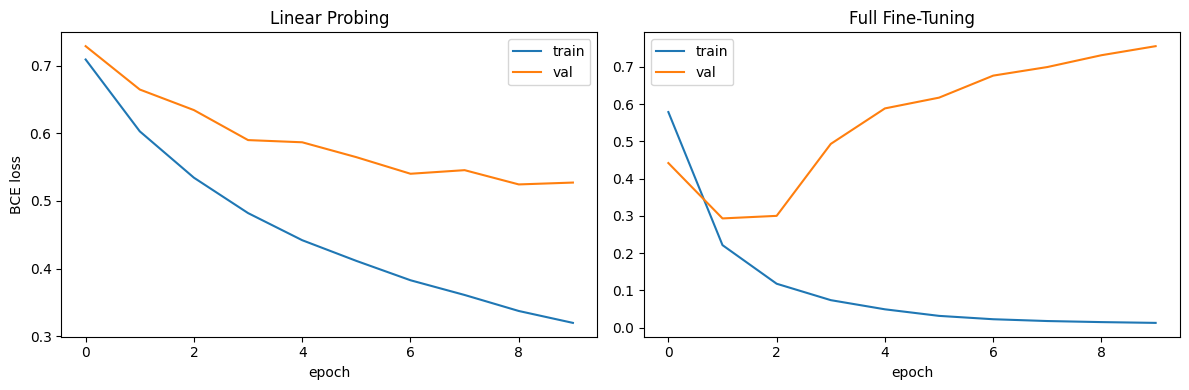

In [ ]:
# ── Training curves - Linear Probing vs Fine-Tuning ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_linear["train_loss"], label="train")
axes[0].plot(history_linear["val_loss"], label="val")
axes[0].set_title("Linear Probing")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].legend()

axes[1].plot(history_finetune["train_loss"], label="train")
axes[1].plot(history_finetune["val_loss"], label="val")
axes[1].set_title("Full Fine-Tuning")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Evaluation on the TEST set ───────────────────────────────────────────────

def evaluate_model(model, loader, device, threshold=0.5):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for pixel_values, labels in loader:
            logits = model(pixel_values.to(device))
            all_logits.append(logits.cpu())
            all_labels.append(labels)

    probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    labels_np = torch.cat(all_labels).numpy().astype(int)
    preds = (probs >= threshold).astype(int)

    per_label = {}
    for i, col in enumerate(LABEL_COLS):
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels_np[:, i], preds[:, i], average="binary", zero_division=0
        )
        try:
            auc = roc_auc_score(labels_np[:, i], probs[:, i])
        except ValueError:
            auc = float("nan")  # happens if the test split has only one class for this label
        per_label[col] = {"precision": precision, "recall": recall, "f1": f1, "auc": auc}

    exact_match = (preds == labels_np).all(axis=1).mean()
    return per_label, exact_match, preds, labels_np


def print_results(name, per_label, exact_match):
    print(f'\n--- {name} ---')
    for col in LABEL_COLS:
        r = per_label[col]
        print(f'  {col:22s}  precision={r["precision"]:.3f}  recall={r["recall"]:.3f}  '
              f'f1={r["f1"]:.3f}  auc={r["auc"]:.3f}')
    print(f'  exact_match_accuracy (all 3 correct at once) = {exact_match:.3f}')


results_linear, exact_linear, preds_linear, labels_test = evaluate_model(model_linear, test_loader, device)
results_finetune, exact_finetune, preds_finetune, _ = evaluate_model(model_finetune, test_loader, device)

print_results("Linear Probing", results_linear, exact_linear)
print_results("Full Fine-Tuning", results_finetune, exact_finetune)


--- Linear Probing ---
  has_ramp                precision=0.790  recall=0.905  f1=0.843  auc=0.870
  has_disabled_parking    precision=0.258  recall=0.632  f1=0.366  auc=0.885
  has_obstacle            precision=0.717  recall=0.195  f1=0.307  auc=0.583
  exact_match_accuracy (all 3 correct at once) = 0.267

--- Full Fine-Tuning ---
  has_ramp                precision=0.711  recall=1.000  f1=0.831  auc=0.905
  has_disabled_parking    precision=1.000  recall=1.000  f1=1.000  auc=1.000
  has_obstacle            precision=1.000  recall=0.036  f1=0.070  auc=0.909
  exact_match_accuracy (all 3 correct at once) = 0.120


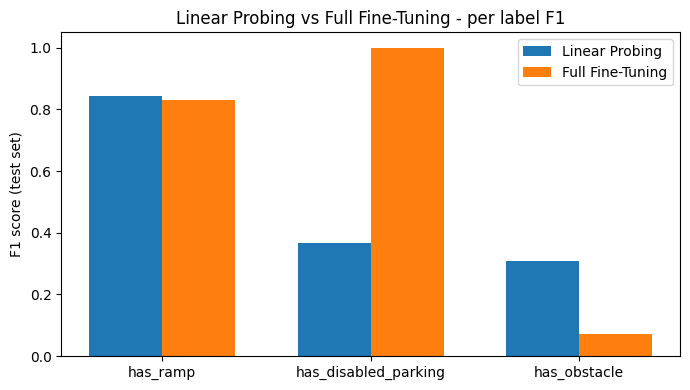

Exact-match accuracy - Linear Probing: 0.267   Full Fine-Tuning: 0.120


In [ ]:
# ── Side-by-side F1 comparison chart ────────────────────────────────────────
import numpy as np

x = np.arange(len(LABEL_COLS))
width = 0.35

f1_linear = [results_linear[c]["f1"] for c in LABEL_COLS]
f1_finetune = [results_finetune[c]["f1"] for c in LABEL_COLS]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, f1_linear, width, label="Linear Probing")
ax.bar(x + width/2, f1_finetune, width, label="Full Fine-Tuning")
ax.set_xticks(x)
ax.set_xticklabels(LABEL_COLS)
ax.set_ylabel("F1 score (test set)")
ax.set_title("Linear Probing vs Full Fine-Tuning - per label F1")
ax.legend()
plt.tight_layout()
plt.show()

print(f'Exact-match accuracy - Linear Probing: {exact_linear:.3f}   Full Fine-Tuning: {exact_finetune:.3f}')

## Sanity check: evaluation on REAL photos

In [ ]:
# ── Load real photos from Drive, labeled by filename ────────────────────────

REAL_IMAGES_DIR = "/content/drive/MyDrive/real_images"  # adjust if your path differs

REAL_CATEGORY_LABELS = {
    "fully_accessible": {"has_ramp": True, "has_disabled_parking": True, "has_obstacle": False},
    "ramp_blocked_by_obstacle": {"has_ramp": True, "has_disabled_parking": False, "has_obstacle": True},
    "stairs_and_ramp": {"has_ramp": True, "has_disabled_parking": False, "has_obstacle": False},
    # NOT explicitly confirmed - inferred from the same naming pattern as the
    # other 3 (every word present in the name = True). Double-check this:
    "ramp_obstacles_disabled_parking": {"has_ramp": True, "has_disabled_parking": True, "has_obstacle": True},
}

sorted_categories = sorted(REAL_CATEGORY_LABELS.keys(), key=len, reverse=True)

real_image_paths = [
    p for p in glob.glob(os.path.join(REAL_IMAGES_DIR, "**", "*.*"), recursive=True)
    if p.lower().endswith((".png", ".jpg", ".jpeg"))
]

real_records, unmatched = [], []
for img_path in real_image_paths:
    fname_lower = os.path.basename(img_path).lower()
    matched_category = next((cat for cat in sorted_categories if cat in fname_lower), None)
    if matched_category is None:
        unmatched.append(img_path)
        continue
    real_records.append({
        "filename": os.path.basename(img_path),
        "path": img_path,
        "category": matched_category,
        **REAL_CATEGORY_LABELS[matched_category],
    })

real_df = pd.DataFrame(real_records)
print(f'Matched {len(real_df)} real images, {len(unmatched)} unmatched')
if unmatched:
    print('Unmatched filenames (check naming against the 4 categories above):')
    print([os.path.basename(p) for p in unmatched])
print('\nPer category:')
print(real_df["category"].value_counts())


Matched 20 real images, 0 unmatched

Per category:
category
stairs_and_ramp             9
fully_accessible            6
ramp_blocked_by_obstacle    5
Name: count, dtype: int64


In [ ]:
# ── Run both trained models on the real photos ──────────────────────────────
real_ds = AccessScanDataset(real_df)
real_loader = DataLoader(real_ds, batch_size=16, shuffle=False, num_workers=0)

print('=== Real-photo generalization check ===')
results_real_linear, exact_real_linear, preds_real_linear, labels_real = evaluate_model(
    model_linear, real_loader, device
)
print_results("Linear Probing (REAL photos)", results_real_linear, exact_real_linear)

results_real_finetune, exact_real_finetune, preds_real_finetune, _ = evaluate_model(
    model_finetune, real_loader, device
)
print_results("Full Fine-Tuning (REAL photos)", results_real_finetune, exact_real_finetune)

=== Real-photo generalization check ===


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



--- Linear Probing (REAL photos) ---
  has_ramp                precision=1.000  recall=0.850  f1=0.919  auc=nan
  has_disabled_parking    precision=0.667  recall=0.667  f1=0.667  auc=0.798
  has_obstacle            precision=0.200  recall=0.400  f1=0.267  auc=0.400
  exact_match_accuracy (all 3 correct at once) = 0.350

--- Full Fine-Tuning (REAL photos) ---
  has_ramp                precision=1.000  recall=1.000  f1=1.000  auc=nan
  has_disabled_parking    precision=0.800  recall=0.667  f1=0.727  auc=0.857
  has_obstacle            precision=0.308  recall=0.800  f1=0.444  auc=0.573
  exact_match_accuracy (all 3 correct at once) = 0.500


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
# ── Per-image detail table (more informative than aggregates on a small set) ─
detail_df = real_df[["filename", "category"] + LABEL_COLS].copy()
detail_df.columns = ["filename", "category"] + [f"true_{c}" for c in LABEL_COLS]

for i, c in enumerate(LABEL_COLS):
    detail_df[f"pred_linear_{c}"] = preds_real_linear[:, i].astype(bool)
    detail_df[f"pred_finetune_{c}"] = preds_real_finetune[:, i].astype(bool)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(detail_df.to_string(index=False))

                         filename                 category  true_has_ramp  true_has_disabled_parking  true_has_obstacle  pred_linear_has_ramp  pred_finetune_has_ramp  pred_linear_has_disabled_parking  pred_finetune_has_disabled_parking  pred_linear_has_obstacle  pred_finetune_has_obstacle
          stairs_and_ramp (8).jpg          stairs_and_ramp           True                      False              False                  True                    True                             False                               False                      True                        True
          stairs_and_ramp (7).jpg          stairs_and_ramp           True                      False              False                  True                    True                             False                               False                     False                       False
          stairs_and_ramp (6).jpg          stairs_and_ramp           True                      False              False           

## Full evaluation: accuracy, error rate, confusion matrix - test set vs. real photos


In [ ]:
# ── Per-label accuracy + confusion matrix, on top of the existing metrics ───
from sklearn.metrics import confusion_matrix, accuracy_score


def compute_full_metrics(preds, labels_np, label_cols=LABEL_COLS):
    metrics = {}
    for i, col in enumerate(label_cols):
        acc = accuracy_score(labels_np[:, i], preds[:, i])
        cm = confusion_matrix(labels_np[:, i], preds[:, i], labels=[0, 1])  # [[TN,FP],[FN,TP]]
        metrics[col] = {"accuracy": acc, "error_rate": 1 - acc, "confusion_matrix": cm}
    return metrics


def run_full_evaluation(model, loader, name):
    """
    Reuses evaluate_model() (precision/recall/f1/auc/exact_match) and adds
    accuracy, error rate and the confusion matrix per label on top of it.
    Prints a full report and returns everything for later comparison/plots.
    """
    per_label, exact_match, preds, labels_np = evaluate_model(model, loader, device)
    full_metrics = compute_full_metrics(preds, labels_np)
    for col in LABEL_COLS:
        full_metrics[col].update(per_label[col])
    full_metrics["exact_match_accuracy"] = exact_match

    print(f'\n{"=" * 70}\n{name}\n{"=" * 70}')
    for col in LABEL_COLS:
        m = full_metrics[col]
        tn, fp, fn, tp = m["confusion_matrix"].ravel()
        print(f'\n[{col}]')
        print(f'  accuracy={m["accuracy"]:.3f}  error_rate={m["error_rate"]:.3f}  '
              f'precision={m["precision"]:.3f}  recall={m["recall"]:.3f}  '
              f'f1={m["f1"]:.3f}  auc={m["auc"]:.3f}')
        print(f'  confusion matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
    print(f'\nexact_match_accuracy (all 3 labels correct at once) = {exact_match:.3f}')

    return full_metrics

print('Full evaluation functions ready')

Full evaluation functions ready


In [ ]:
# ── Run all 4 combinations: {Linear Probing, Full Fine-Tuning} x {test, real} ─
metrics_lp_test = run_full_evaluation(model_linear, test_loader, "Linear Probing - TEST set (synthetic)")
metrics_ft_test = run_full_evaluation(model_finetune, test_loader, "Full Fine-Tuning - TEST set (synthetic)")
metrics_lp_real = run_full_evaluation(model_linear, real_loader, "Linear Probing - REAL photos")
metrics_ft_real = run_full_evaluation(model_finetune, real_loader, "Full Fine-Tuning - REAL photos")


Linear Probing - TEST set (synthetic)

[has_ramp]
  accuracy=0.772  error_rate=0.228  precision=0.790  recall=0.905  f1=0.843  auc=0.870
  confusion matrix:  TN=116  FP=122  FN=48  TP=458

[has_disabled_parking]
  accuracy=0.888  error_rate=0.112  precision=0.258  recall=0.632  f1=0.366  auc=0.885
  confusion matrix:  TN=637  FP=69  FN=14  TP=24

[has_obstacle]
  accuracy=0.448  error_rate=0.552  precision=0.717  recall=0.195  f1=0.307  auc=0.583
  confusion matrix:  TN=242  FP=36  FN=375  TP=91

exact_match_accuracy (all 3 labels correct at once) = 0.267

Full Fine-Tuning - TEST set (synthetic)

[has_ramp]
  accuracy=0.723  error_rate=0.277  precision=0.711  recall=1.000  f1=0.831  auc=0.905
  confusion matrix:  TN=32  FP=206  FN=0  TP=506

[has_disabled_parking]
  accuracy=1.000  error_rate=0.000  precision=1.000  recall=1.000  f1=1.000  auc=1.000
  confusion matrix:  TN=706  FP=0  FN=0  TP=38

[has_obstacle]
  accuracy=0.397  error_rate=0.603  precision=1.000  recall=0.036  f1=0.07

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



Linear Probing - REAL photos

[has_ramp]
  accuracy=0.850  error_rate=0.150  precision=1.000  recall=0.850  f1=0.919  auc=nan
  confusion matrix:  TN=0  FP=0  FN=3  TP=17

[has_disabled_parking]
  accuracy=0.800  error_rate=0.200  precision=0.667  recall=0.667  f1=0.667  auc=0.798
  confusion matrix:  TN=12  FP=2  FN=2  TP=4

[has_obstacle]
  accuracy=0.450  error_rate=0.550  precision=0.200  recall=0.400  f1=0.267  auc=0.400
  confusion matrix:  TN=7  FP=8  FN=3  TP=2

exact_match_accuracy (all 3 labels correct at once) = 0.350

Full Fine-Tuning - REAL photos

[has_ramp]
  accuracy=1.000  error_rate=0.000  precision=1.000  recall=1.000  f1=1.000  auc=nan
  confusion matrix:  TN=0  FP=0  FN=0  TP=20

[has_disabled_parking]
  accuracy=0.850  error_rate=0.150  precision=0.800  recall=0.667  f1=0.727  auc=0.857
  confusion matrix:  TN=13  FP=1  FN=2  TP=4

[has_obstacle]
  accuracy=0.500  error_rate=0.500  precision=0.308  recall=0.800  f1=0.444  auc=0.573
  confusion matrix:  TN=6  FP=9

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
# ── Side-by-side accuracy comparison table ──────────────────────────────────
comparison_rows = []
for col in LABEL_COLS:
    comparison_rows.append({
        "label": col,
        "LP_test_acc": metrics_lp_test[col]["accuracy"],
        "FT_test_acc": metrics_ft_test[col]["accuracy"],
        "LP_real_acc": metrics_lp_real[col]["accuracy"],
        "FT_real_acc": metrics_ft_real[col]["accuracy"],
    })
comparison_df = pd.DataFrame(comparison_rows)

print(comparison_df.to_string(index=False))
print(f'\nexact_match_accuracy:  LP_test={metrics_lp_test["exact_match_accuracy"]:.3f}  '
      f'FT_test={metrics_ft_test["exact_match_accuracy"]:.3f}  '
      f'LP_real={metrics_lp_real["exact_match_accuracy"]:.3f}  '
      f'FT_real={metrics_ft_real["exact_match_accuracy"]:.3f}')

               label  LP_test_acc  FT_test_acc  LP_real_acc  FT_real_acc
            has_ramp     0.771505     0.723118         0.85         1.00
has_disabled_parking     0.888441     1.000000         0.80         0.85
        has_obstacle     0.447581     0.396505         0.45         0.50

exact_match_accuracy:  LP_test=0.267  FT_test=0.120  LP_real=0.350  FT_real=0.500


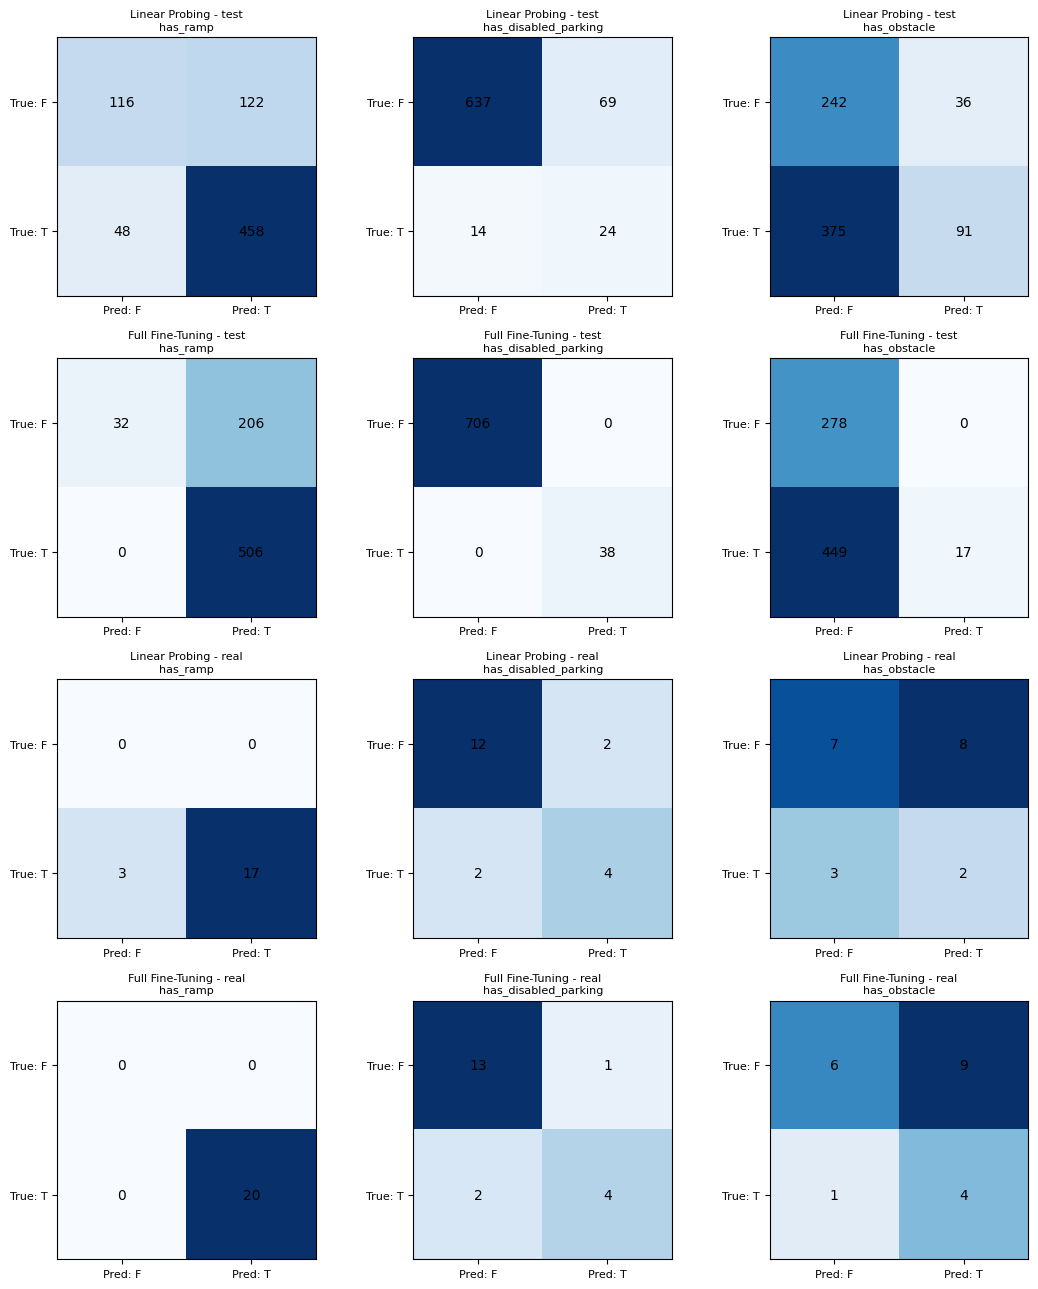

In [ ]:
# ── Confusion matrix grid: 4 experiments x 3 labels ──────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(11, 13))

row_configs = [
    ("Linear Probing - test", metrics_lp_test),
    ("Full Fine-Tuning - test", metrics_ft_test),
    ("Linear Probing - real", metrics_lp_real),
    ("Full Fine-Tuning - real", metrics_ft_real),
]

for row_idx, (row_name, metrics) in enumerate(row_configs):
    for col_idx, col in enumerate(LABEL_COLS):
        ax = axes[row_idx, col_idx]
        cm = metrics[col]["confusion_matrix"]
        ax.imshow(cm, cmap="Blues", vmin=0)
        for (i, j), val in np.ndenumerate(cm):
            ax.text(j, i, str(val), ha="center", va="center", fontsize=10)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: F", "Pred: T"], fontsize=8)
        ax.set_yticks([0, 1]); ax.set_yticklabels(["True: F", "True: T"], fontsize=8)
        ax.set_title(f'{row_name}\n{col}', fontsize=8)

plt.tight_layout()
plt.show()

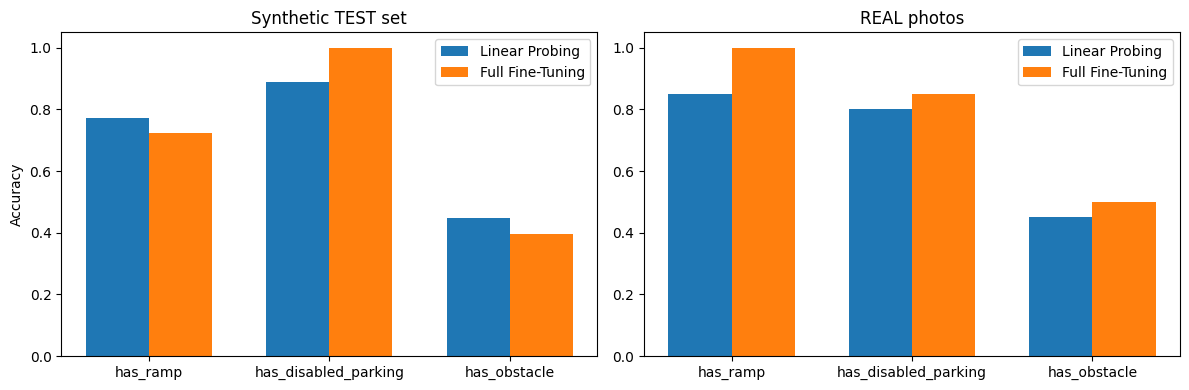

In [ ]:
# ── Accuracy bar chart: Linear Probing vs Full Fine-Tuning, test vs real ────
x = np.arange(len(LABEL_COLS))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

acc_lp_test = [metrics_lp_test[c]["accuracy"] for c in LABEL_COLS]
acc_ft_test = [metrics_ft_test[c]["accuracy"] for c in LABEL_COLS]
axes[0].bar(x - width/2, acc_lp_test, width, label="Linear Probing")
axes[0].bar(x + width/2, acc_ft_test, width, label="Full Fine-Tuning")
axes[0].set_xticks(x); axes[0].set_xticklabels(LABEL_COLS)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Synthetic TEST set")
axes[0].legend()

acc_lp_real = [metrics_lp_real[c]["accuracy"] for c in LABEL_COLS]
acc_ft_real = [metrics_ft_real[c]["accuracy"] for c in LABEL_COLS]
axes[1].bar(x - width/2, acc_lp_real, width, label="Linear Probing")
axes[1].bar(x + width/2, acc_ft_real, width, label="Full Fine-Tuning")
axes[1].set_xticks(x); axes[1].set_xticklabels(LABEL_COLS)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("REAL photos")
axes[1].legend()

plt.tight_layout()
plt.show()